In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드
ev_df = pd.read_csv('/home/dahyun/ml_sol/datas_ml/ev_energy_consumption.csv')
ev_df.info()

ev_df['speed_payload'] = ev_df['speed_kmh'] * ev_df['payload_kg']
ev_df['hvac_temp']     = ev_df['hvac_power_kw'] * ev_df['ambient_temp_C']
ev_df['speed_squared'] = ev_df['speed_kmh'] ** 2
ev_df['tire_payload']  = ev_df['tire_pressure_bar'] * ev_df['payload_kg']

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   speed_kmh                       8000 non-null   float64
 1   payload_kg                      8000 non-null   float64
 2   ambient_temp_C                  8000 non-null   float64
 3   hvac_power_kw                   8000 non-null   float64
 4   road_grade_pct                  8000 non-null   float64
 5   battery_temp_C                  8000 non-null   float64
 6   driving_style_index             8000 non-null   float64
 7   tire_pressure_bar               8000 non-null   float64
 8   trip_distance_km                8000 non-null   float64
 9   energy_consumption_kwhper100km  8000 non-null   float64
dtypes: float64(10)
memory usage: 625.1 KB


In [29]:
ev_df.describe()

,speed_kmh,payload_kg,ambient_temp_C,hvac_power_kw,road_grade_pct,battery_temp_C,driving_style_index,tire_pressure_bar,trip_distance_km,energy_consumption_kwhper100km,speed_payload,hvac_temp,speed_squared,tire_payload
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,74.427013,248.822563,15.587013,2.477026,1.464087,29.970725,0.499641,2.401016,102.692337,24.137613,18513.831974,38.480497,6549.809951,597.450633
std,31.789245,144.327869,14.396150,1.435208,3.744704,8.717058,0.286885,0.230790,55.844911,3.738082,14110.454962,46.941537,4839.322352,353.106647
min,20.000000,0.000000,-10.000000,0.000000,-5.000000,15.000000,0.000000,2.000000,5.100000,11.620000,0.000000,-46.300000,400.000000,0.000000
25%,46.775000,124.300000,3.475000,1.230000,-1.790000,22.300000,0.254000,2.200000,54.300000,21.514000,7174.725000,3.358500,2187.902500,293.508000
50%,74.200000,246.850000,15.800000,2.480000,1.500000,29.900000,0.502000,2.400000,103.250000,24.092500,15058.190000,25.424000,5505.640000,588.000000
75%,101.800000,376.125000,27.900000,3.700000,4.670000,37.700000,0.745000,2.600000,151.700000,26.753000,27441.405000,65.132000,10363.240000,893.584500
max,130.000000,500.000000,40.000000,5.000000,8.000000,45.000000,1.000000,2.800000,200.000000,35.000000,64309.840000,196.606000,16900.000000,1384.880000


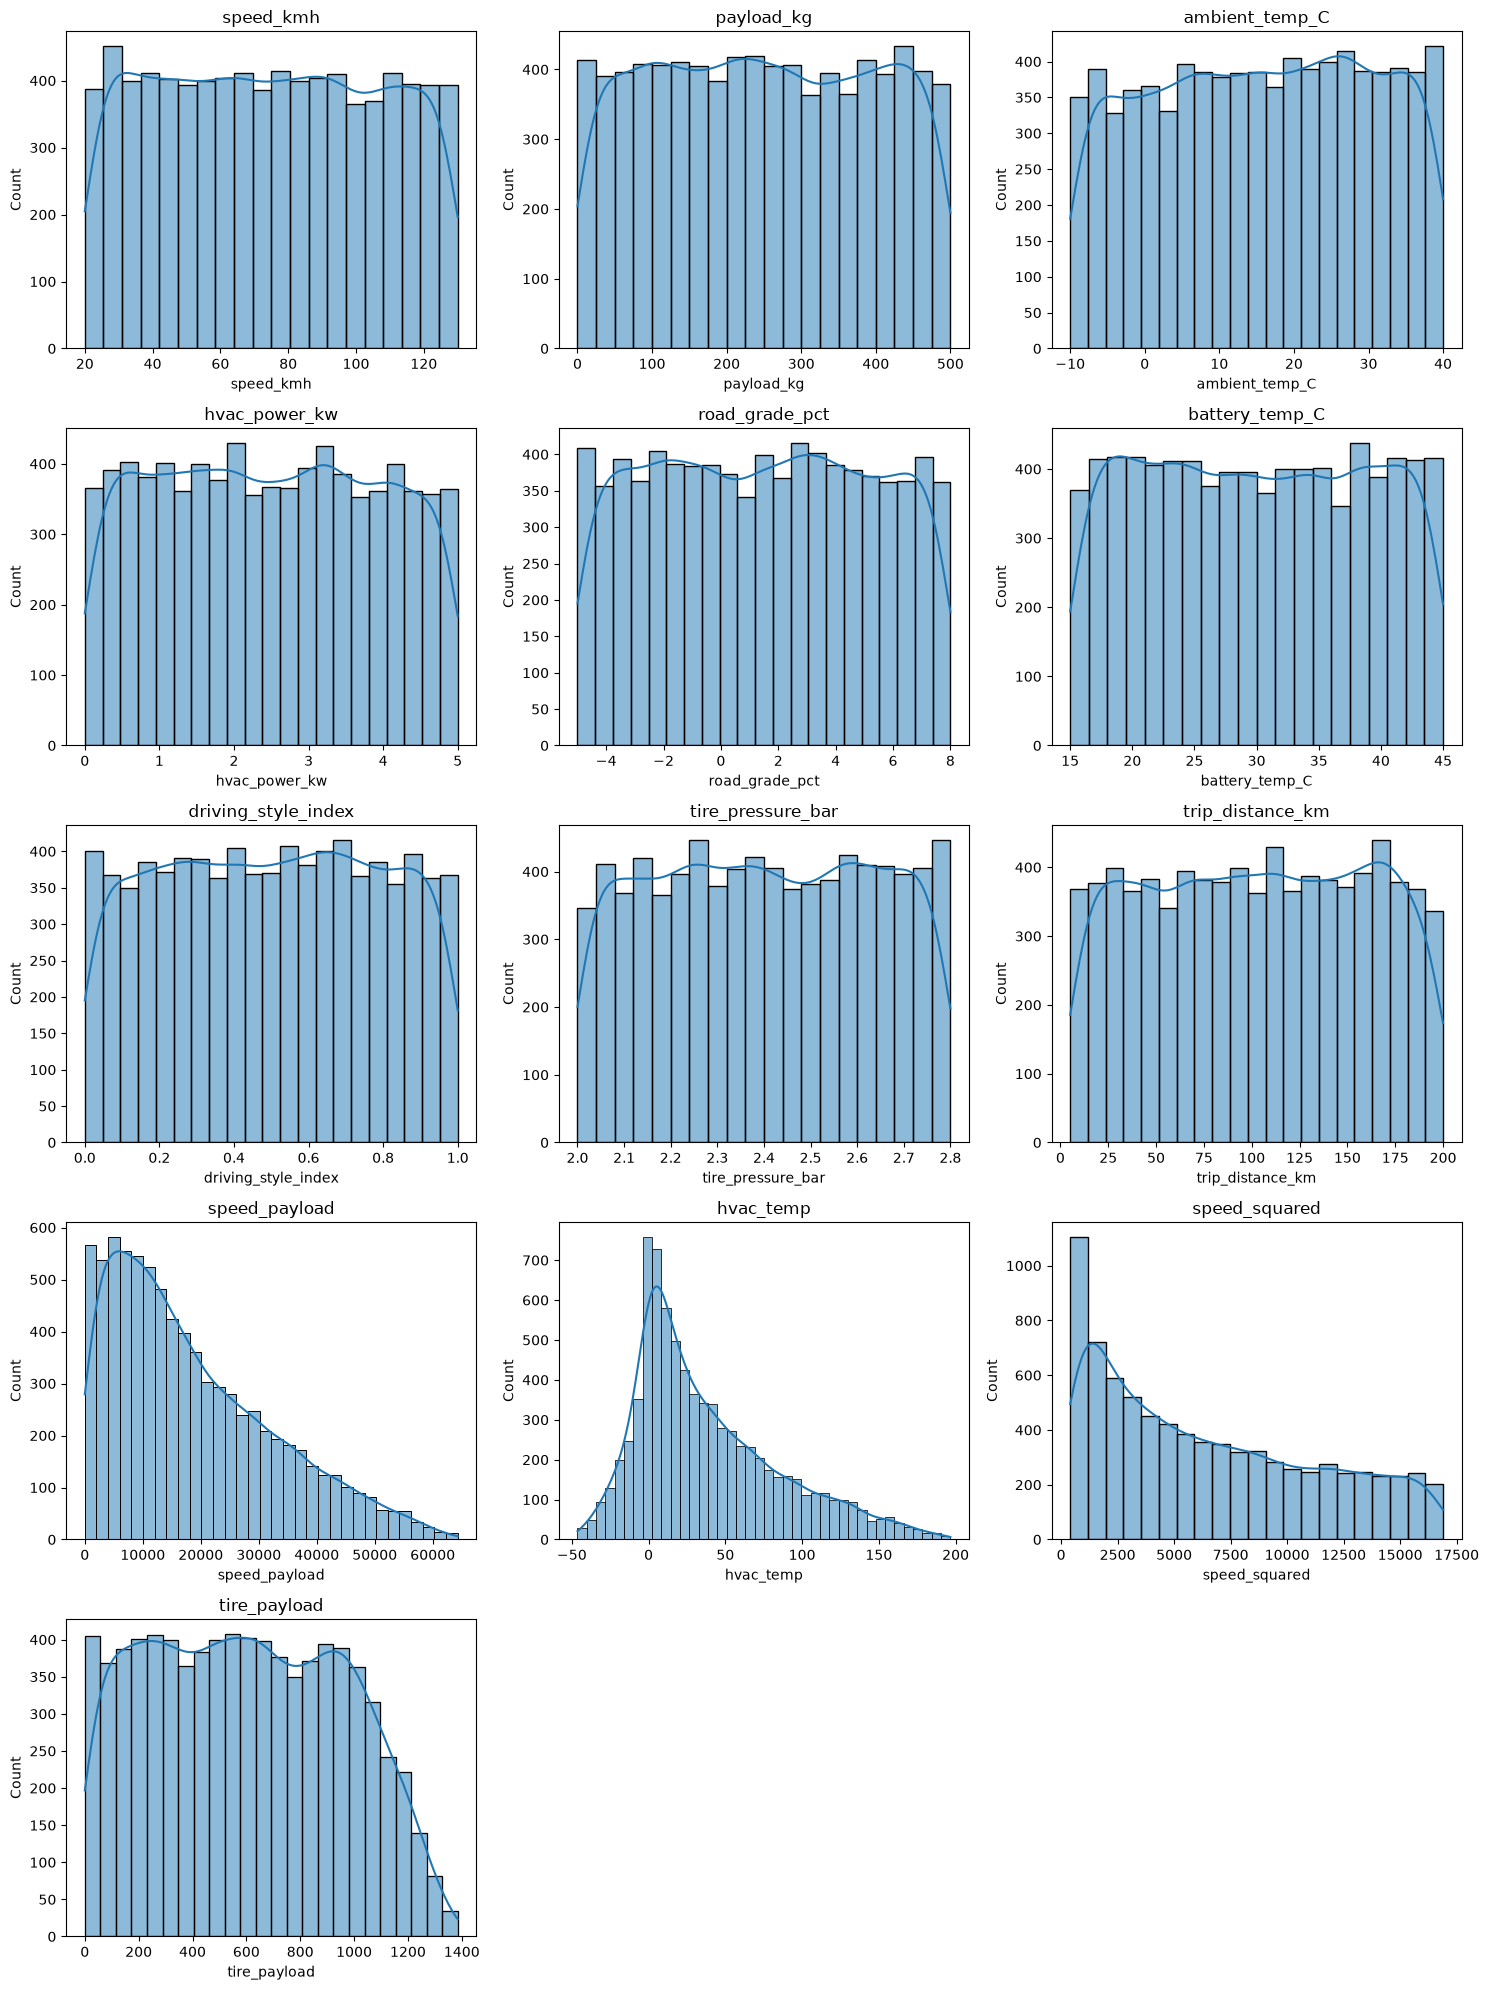

In [31]:
# 2. EDA - 데이터 분포 확인
col_names = [col for col in ev_df.columns if col != 'energy_consumption_kwhper100km']

# col_names 개수에 맞게 자동으로 행 수 계산
ncols = 3
nrows = -(-len(col_names) // ncols)  # 올림 나눗셈

figure, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4))

for i, col in enumerate(col_names):
    row, col_idx = divmod(i, ncols)
    sns.histplot(data=ev_df, x=col, ax=axes[row, col_idx], kde=True)
    axes[row, col_idx].set_title(col)

# 남는 빈 칸 숨기기
for j in range(len(col_names), nrows * ncols):
    row, col_idx = divmod(j, ncols)
    axes[row, col_idx].set_visible(False)

plt.tight_layout()
plt.show()

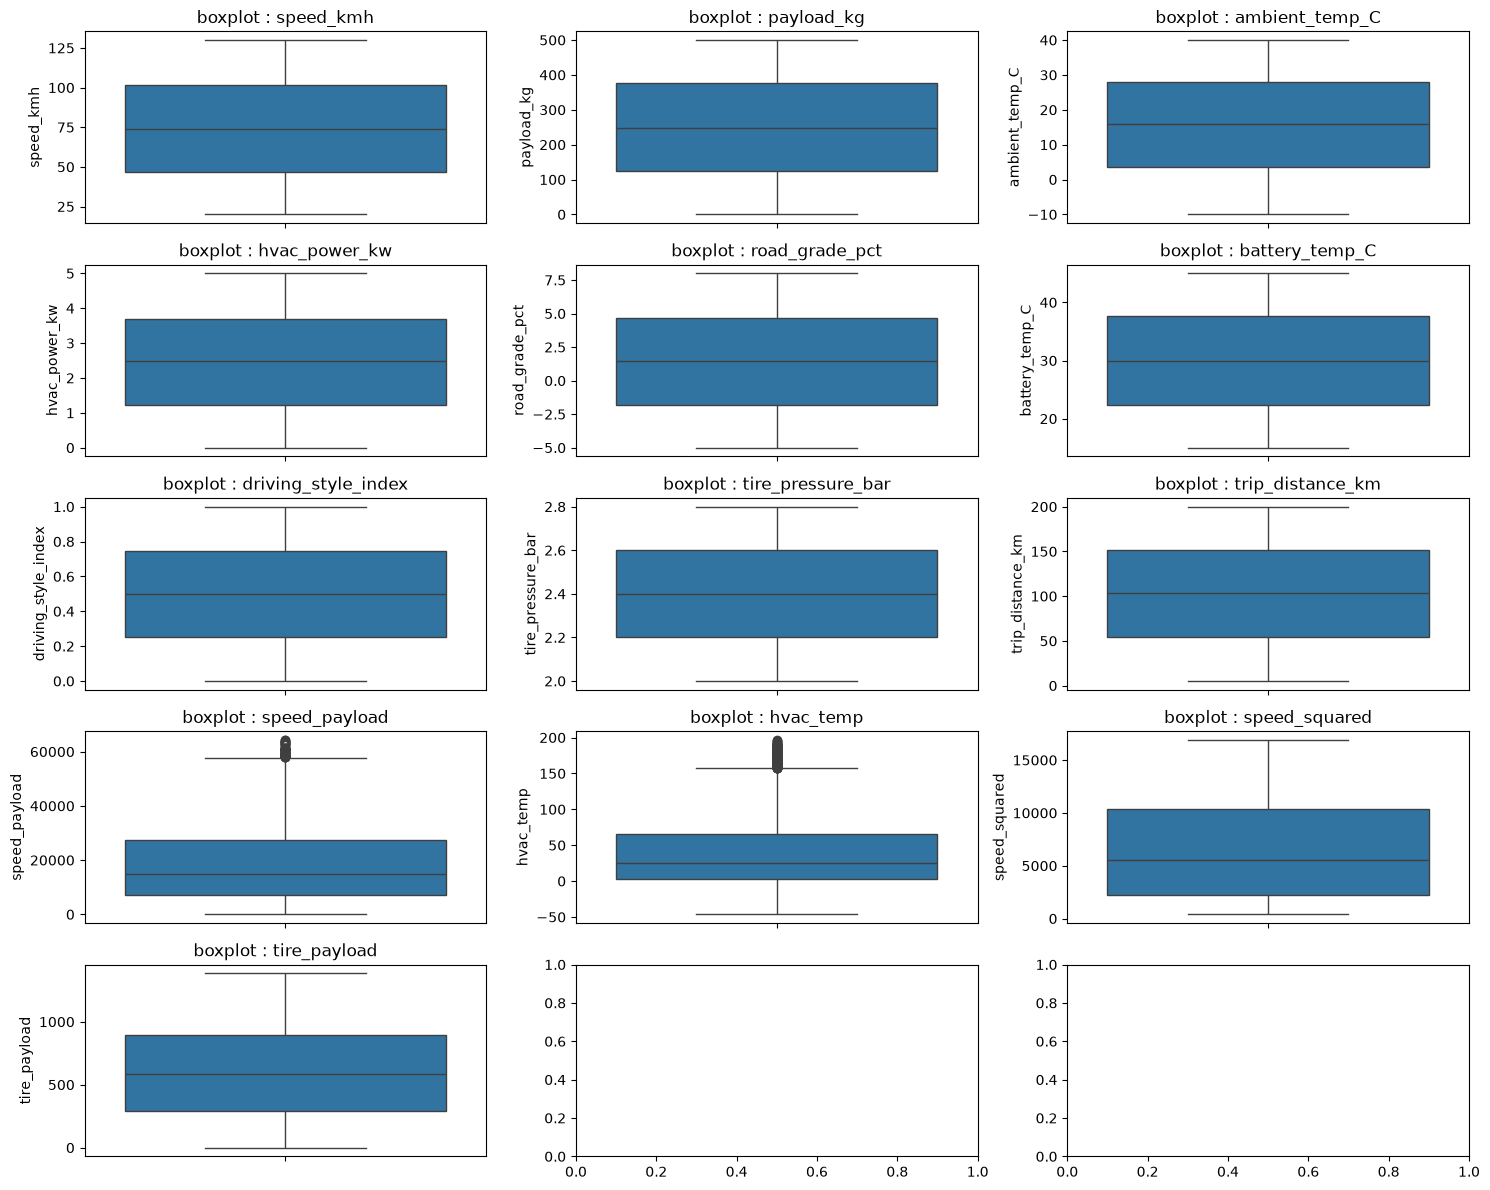

In [32]:
# 3. 이상치 확인 - boxplot
figure, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 12))

for i, col in enumerate(col_names):
    row, col_idx = divmod(i, ncols)
    sns.boxplot(data=ev_df, y=col, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'boxplot : {col}')

plt.tight_layout()
plt.show()

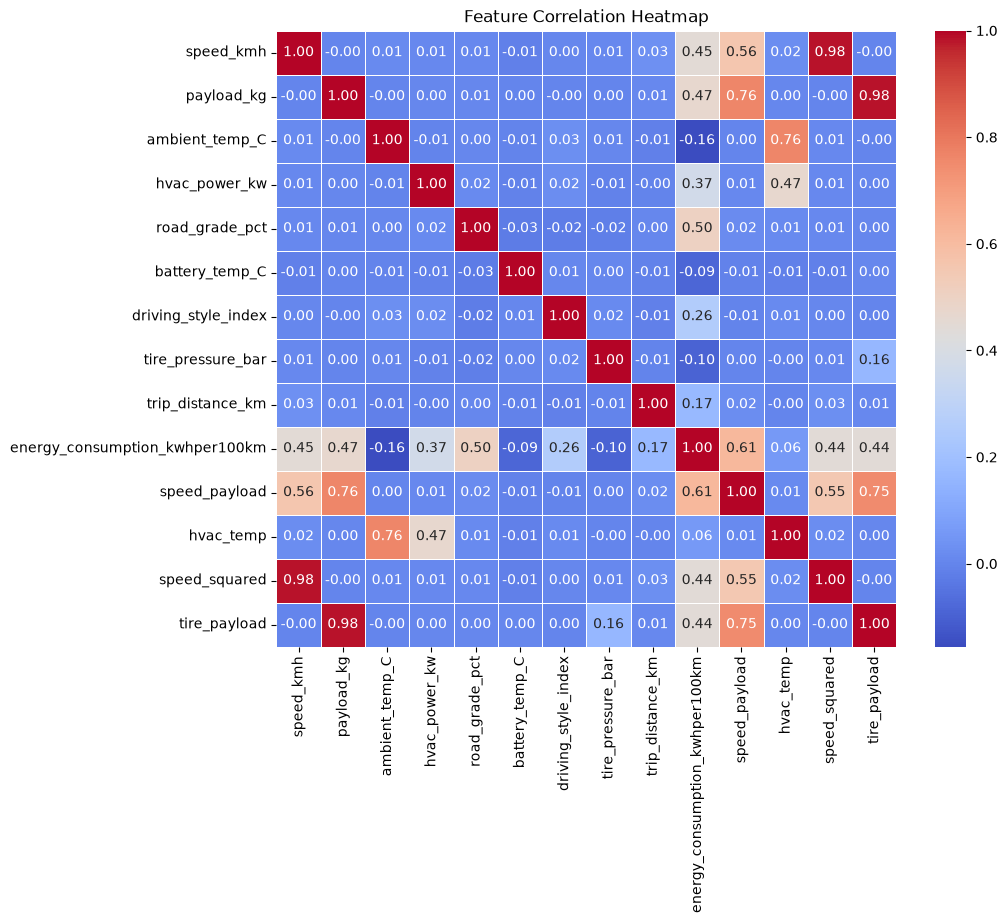

In [33]:
# 4. 상관관계 히트맵
plt.figure(figsize=(10, 8))
sns.heatmap(ev_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [34]:
# 5. 결측값 처리
print(ev_df.isnull().sum())
ev_df = ev_df.dropna()

speed_kmh                         0
payload_kg                        0
ambient_temp_C                    0
hvac_power_kw                     0
road_grade_pct                    0
battery_temp_C                    0
driving_style_index               0
tire_pressure_bar                 0
trip_distance_km                  0
energy_consumption_kwhper100km    0
speed_payload                     0
hvac_temp                         0
speed_squared                     0
tire_payload                      0
dtype: int64


In [35]:
# 6. 독립변수 / 종속변수 분리 (road_grade_pct 제외)
X = ev_df.drop(columns=['energy_consumption_kwhper100km', 'road_grade_pct'])
y = ev_df['energy_consumption_kwhper100km']

print(X.shape, y.shape)

(8000, 12) (8000,)


In [36]:
# 7. 피처 스케일링 (RobustScaler - 이상치 대응)
from sklearn.preprocessing import RobustScaler

X_scaled = RobustScaler().fit_transform(X)

In [37]:
# 8. 데이터 분리
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(6400, 12) (1600, 12)


In [38]:
# 9. 모델 학습 및 평가
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    'LinearRegression'   : LinearRegression(),
    'KNN'                : KNeighborsRegressor(),
    'RandomForest'       : RandomForestRegressor(random_state=42),
    'GradientBoosting'   : GradientBoostingRegressor(random_state=42),
    'XGBoost'            : XGBRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append({
        'Model' : name,
        'MAE'   : mean_absolute_error(y_test, pred),
        'RMSE'  : np.sqrt(mean_squared_error(y_test, pred)),
        'R2'    : r2_score(y_test, pred)
    })

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print(results_df)

              Model       MAE      RMSE        R2
3  GradientBoosting  1.707499  2.057538  0.686741
0  LinearRegression  1.737628  2.076742  0.680867
2      RandomForest  1.739155  2.107311  0.671402
4           XGBoost  1.824185  2.220429  0.635178
1               KNN  1.858418  2.278929  0.615702


In [39]:
# 10. XGBoost GridSearchCV 하이퍼파라미터 튜닝
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators'  : [100, 200, 300],
    'max_depth'     : [3, 5, 7],
    'learning_rate' : [0.01, 0.1, 0.3],
    'subsample'     : [0.7, 0.8, 1.0]
}

xgb_grid_cv = GridSearchCV(XGBRegressor(random_state=42),
                            param_grid=params,
                            cv=3,
                            scoring='r2',
                            n_jobs=-1)
xgb_grid_cv.fit(X_train, y_train)

print('Best Params :', xgb_grid_cv.best_params_)
print('Best Score  :', xgb_grid_cv.best_score_)

Best Params : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best Score  : 0.685103623097925


In [40]:
# 11. 최적 XGBoost 모델 평가
best_xgb = xgb_grid_cv.best_estimator_
xgb_pred = best_xgb.predict(X_test)

print(f"MAE  : {mean_absolute_error(y_test, xgb_pred):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, xgb_pred)):.4f}")
print(f"R2   : {r2_score(y_test, xgb_pred):.4f}")

MAE  : 1.6963
RMSE : 2.0387
R2   : 0.6925


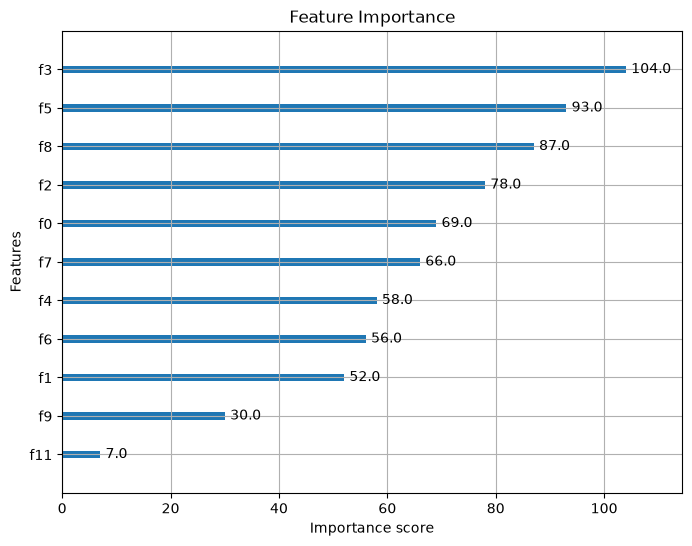

In [41]:
# 12. Feature Importance 시각화
from xgboost import plot_importance

fig, ax = plt.subplots(figsize=(8, 6))
plot_importance(best_xgb, ax=ax)
plt.title('Feature Importance')
plt.show()

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

params = {
    'n_estimators'  : [100, 200, 300],
    'max_depth'     : [3, 5, 7],
    'learning_rate' : [0.01, 0.1, 0.3],
    'subsample'     : [0.7, 0.8, 1.0]
}

gb_grid_cv = GridSearchCV(GradientBoostingRegressor(random_state=42),
                           param_grid=params,
                           cv=3,
                           scoring='r2',
                           n_jobs=-1)
gb_grid_cv.fit(X_train, y_train)

print('Best Params :', gb_grid_cv.best_params_)
print('Best CV R2  :', gb_grid_cv.best_score_)

Best Params : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}
Best CV R2  : 0.686215307668881


In [45]:
# 최적 모델 평가
best_gb = gb_grid_cv.best_estimator_
gb_pred = best_gb.predict(X_test)

print(f"MAE  : {mean_absolute_error(y_test, gb_pred):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, gb_pred)):.4f}")
print(f"R2   : {r2_score(y_test, gb_pred):.4f}")

MAE  : 1.7098
RMSE : 2.0526
R2   : 0.6882


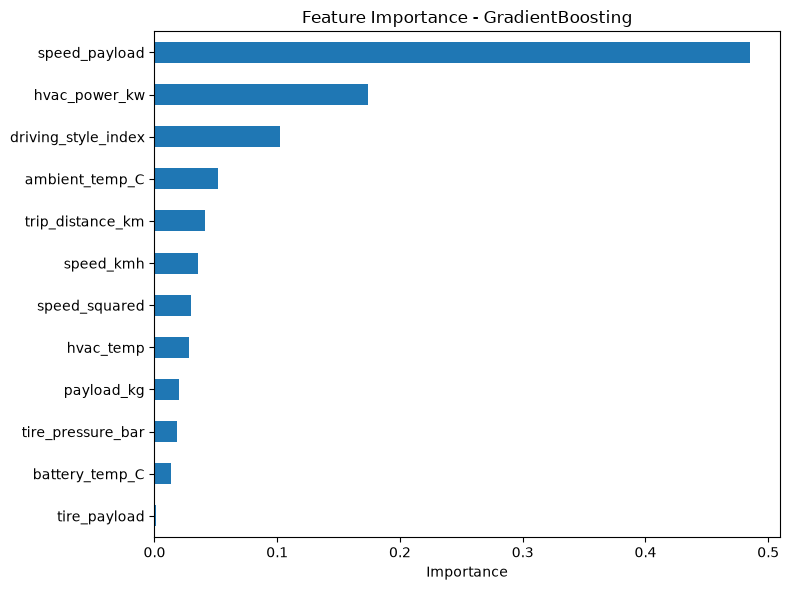

In [46]:
# Feature Importance 시각화
feat_importance = pd.Series(best_gb.feature_importances_, index=X.columns)
feat_importance = feat_importance.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
feat_importance.plot(kind='barh')
plt.title('Feature Importance - GradientBoosting')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [47]:
# road_grade_pct 포함 모델
X_with_grade = ev_df.drop(columns=['energy_consumption_kwhper100km'])
y_with = ev_df['energy_consumption_kwhper100km']

X_scaled_with = RobustScaler().fit_transform(X_with_grade)
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_scaled_with, y_with, test_size=0.2, random_state=42
)

gb_with = GradientBoostingRegressor(
    learning_rate=0.1, max_depth=3, n_estimators=100,
    subsample=0.7, random_state=42
)
gb_with.fit(X_train_w, y_train_w)
pred_with = gb_with.predict(X_test_w)

# road_grade_pct 제외 모델
X_without_grade = ev_df.drop(columns=['energy_consumption_kwhper100km', 'road_grade_pct'])
X_scaled_without = RobustScaler().fit_transform(X_without_grade)
X_train_wo, X_test_wo, y_train_wo, y_test_wo = train_test_split(
    X_scaled_without, y_with, test_size=0.2, random_state=42
)

gb_without = GradientBoostingRegressor(
    learning_rate=0.1, max_depth=3, n_estimators=100,
    subsample=0.7, random_state=42
)
gb_without.fit(X_train_wo, y_train_wo)
pred_without = gb_without.predict(X_test_wo)

print('=== road_grade_pct 포함 ===')
print(f"MAE  : {mean_absolute_error(y_test_w, pred_with):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test_w, pred_with)):.4f}")
print(f"R2   : {r2_score(y_test_w, pred_with):.4f}")

print('\n=== road_grade_pct 제외 ===')
print(f"MAE  : {mean_absolute_error(y_test_wo, pred_without):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test_wo, pred_without)):.4f}")
print(f"R2   : {r2_score(y_test_wo, pred_without):.4f}")

=== road_grade_pct 포함 ===
MAE  : 0.7559
RMSE : 0.9497
R2   : 0.9333

=== road_grade_pct 제외 ===
MAE  : 1.7098
RMSE : 2.0526
R2   : 0.6882
